# 2_eda_timeseries – Explorative Analyse des Stromverbrauchs

In diesem Notebook werden die bereinigten Smart-Meter-Daten explorativ analysiert.

Ziele:

- Grundlegender Überblick über die Zeitreihe
- Analyse von Tages- und Wochenmustern
- Untersuchung saisonaler Muster (Wochen/Monate, Trends)
- Peak Detection (ohne Machine Learning)
- Korrelationsanalyse der wichtigsten Energie-Variablen
- Speichern relevanter Visualisierungen für README / Power BI / Streamlit


## 1. Imports von Bibliotheken und Einstellungen

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Darstellungseinstellungen für Plots
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# Warnungen etwas reduzieren
import warnings
warnings.filterwarnings("ignore")

## 2. Daten laden

In [56]:
# Pfad zur bereinigten Datei (aus Phase 1)
pfad_bearbeitet="C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Data\\bearbeitet\\household_power_clean.csv"


In [59]:
# DataFrame laden
# Annahme: Spalte 'Datetime' wurde in Notebook 1 bereits erzeugt und bereinigt
df = pd.read_csv(
    pfad_bearbeitet,
    parse_dates=['Datetime'],
    index_col='Datetime',
    sep=',',
    decimal=','   # ← Wichtig für deutsche Zahlenformate
)
# Erste Zeilen anzeigen
df.head(3)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.36,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0


## 3. Datentypen prüfen (Sicherheits-Check)

In [61]:
df.dtypes

Global_active_power      object
Global_reactive_power    object
Voltage                  object
Global_intensity         object
Sub_metering_1           object
Sub_metering_2           object
Sub_metering_3           object
dtype: object

In [62]:
# Relevante numerische Spalten (wie im Cleaning-Notebook definiert)
num_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

# Falls noch Strings / Komma-Formate vorhanden sind -> in float umwandeln
for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)                    # sicherheitshalber
        .str.replace(',', '.', regex=False)  # Dezimal-Komma -> Punkt
        .astype(float)                  # in float umwandeln
    )

# Noch einmal prüfen
df[num_cols].dtypes

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

## Überblick: Stromverbrauch über Zeit

Ziel: Ein erster visueller Eindruck – gibt es Ausreißer, Lücken, Trends?

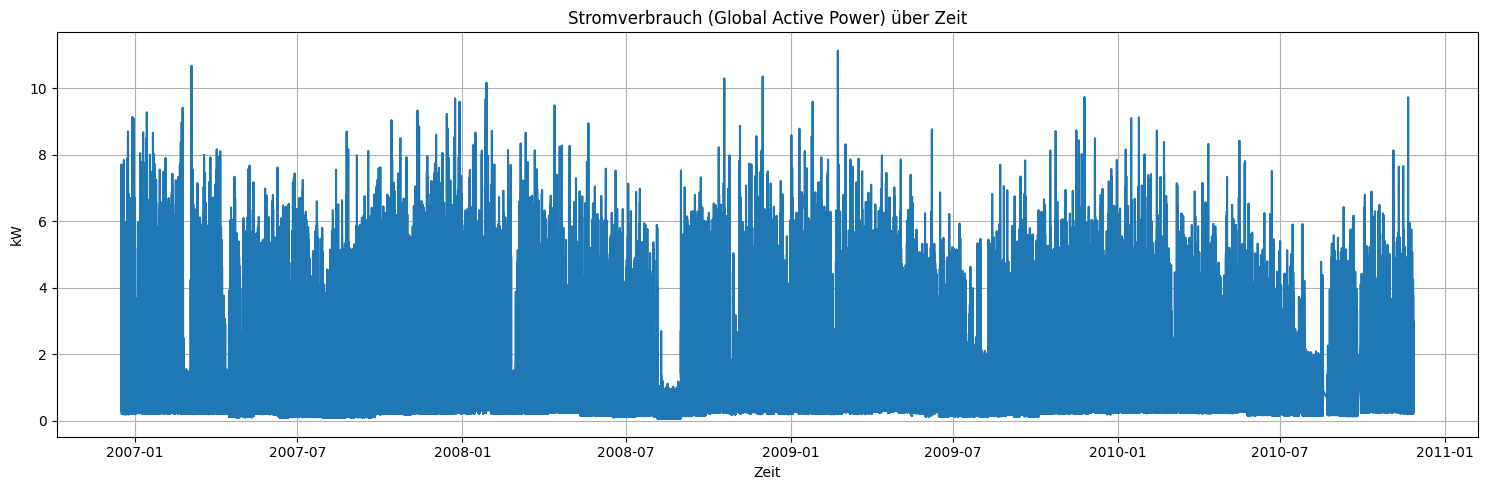

In [63]:
plt.figure(figsize=(15, 5))
plt.plot(df["Global_active_power"])
plt.title("Stromverbrauch (Global Active Power) über Zeit")
plt.xlabel("Zeit")
plt.ylabel("kW")
plt.tight_layout()
plt.show()


###  Beobachtungen aus der Zeitreihenübersicht

- **Langer Zeitraum (2007–2010):** Gute Grundlage für saisonale und langfristige Analysen.
- **Deutliche Verbrauchsspitzen:** Peaks >10 kW → mögliche Anomalien oder energiestarke Geräte.
- **Typische Tagesmuster:** Hochfrequente Zacken deuten auf haushaltstypisches Verbrauchsverhalten hin.
- **Auffällige Abfälle/Lücken in 2008 und 2010:** Wahrscheinlich Messausfälle, sollten bei Modellen berücksichtigt werden.
- **Trendverhalten:** Leichter Anstieg bis 2009, deutlicher Rückgang 2010 → relevant für Forecasting und Anomalieerkennung.



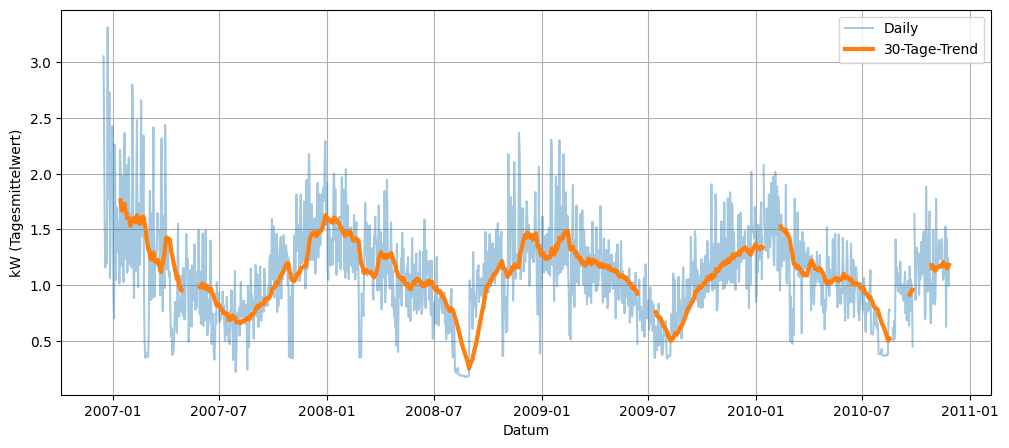

In [98]:
df_daily_rolling = df_daily.rolling(30).mean()  # 30-Tage-Trend
plt.plot(df_daily, alpha=0.4, label="Daily")
plt.plot(df_daily_rolling, label="30-Tage-Trend", linewidth=3)
plt.xlabel("Datum")
plt.ylabel("kW (Tagesmittelwert)")
plt.legend(loc="upper right")
plt.show()

### Beobachtungen aus dem 30-Tage-Trend

- **Deutliche Saisonalität:** Verbrauch steigt im Winter und sinkt klar im Sommer.
- **Regelmäßige Jahreszyklen:** Die Peaks liegen typischerweise zwischen Dezember–Februar.
- **Niedrigste Verbräuche im Hochsommer:** Besonders sichtbar Mitte 2008, 2009 und 2010.
- **Trendänderungen:** 2010 sinkt der Gesamtverbrauch über das Jahr deutlicher als zuvor.
- **Messlücken fallen weniger ins Gewicht:** Der Rolling Mean glättet Datenfehler gut.


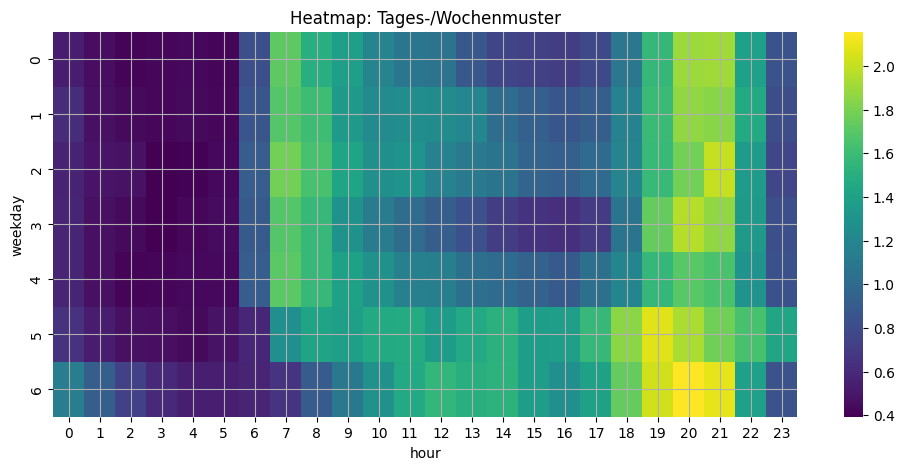

In [95]:
df['hour'] = df.index.hour
df['weekday'] = df.index.dayofweek
pivot = df.pivot_table(index='weekday', columns='hour', values='Global_active_power', aggfunc='mean')
sns.heatmap(pivot, cmap='viridis')
plt.title("Heatmap: Tages-/Wochenmuster")
plt.show()


### Beobachtungen aus der Heatmap (Tages-/Wochenmuster)

- **Morgens (ca. 7–10 Uhr)** steigt der Verbrauch an allen Wochentagen deutlich an → typisches Haushaltsverhalten (Frühstück, Warmwasser, Heizen).
- **Mittags (ca. 11–15 Uhr)** liegt der Verbrauch eher im mittleren Bereich – an Werktagen etwas niedriger als am Wochenende.
- **Abends (ca. 18–22 Uhr)** treten die höchsten Verbrauchswerte auf → Hauptaktivitätszeit im Haushalt (Kochen, Geräte, Licht).
- **Werktage (0–4)** zeigen ein gleichmäßigeres Muster, besonders mittags sinkt der Verbrauch stärker.
- **Wochenende (5–6)** hat:
  - spätere Morgenpeaks (Haushalt startet später)
  - dauerhaft etwas höhere Werte tagsüber
  - die **stärksten Peaks am Abend**, besonders samstags.
- **Nachtstunden (0–5 Uhr)** sind an allen Tagen sehr niedrig → guter Indikator für Grundlastniveau.


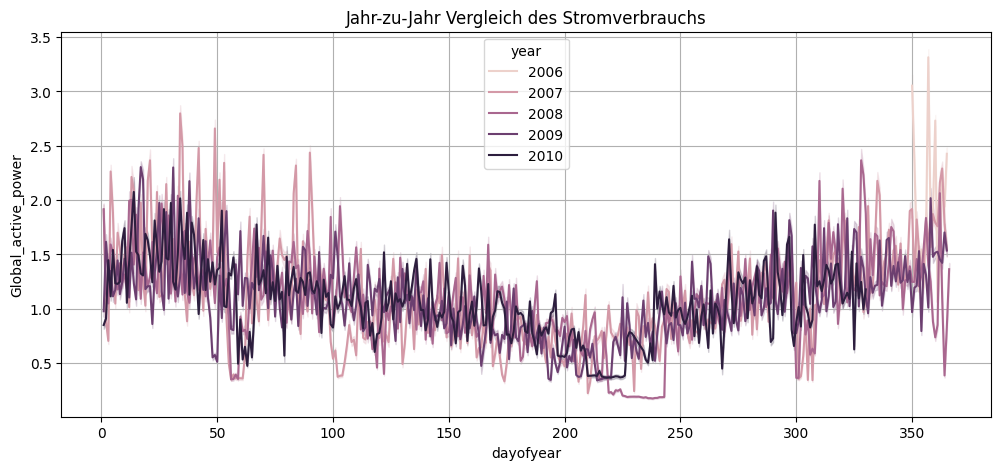

In [96]:
df["year"] = df.index.year
df["dayofyear"] = df.index.dayofyear

sns.lineplot(data=df, x="dayofyear", y="Global_active_power", hue="year")
plt.title("Jahr-zu-Jahr Vergleich des Stromverbrauchs")
plt.show()


###  Beobachtungen: Jahr-zu-Jahr Vergleich

- Die saisonalen Muster (Winter hoch, Sommer niedrig) wiederholen sich über die Jahre hinweg.
- 2010 zeigt insgesamt einen niedrigeren Verbrauch → möglicher Verhaltens- oder Geräteeffekt.
- 2006 ist unvollständig, daher nur eingeschränkt nutzbar.
- Messausfälle sind sichtbar (besonders in 2008), was für die Modellierung berücksichtigt werden muss.
- Der Vergleich hilft zu verstehen, ob Peaks oder Verbrauchsänderungen normal saisonal sind oder potenzielle Anomalien darstellen.


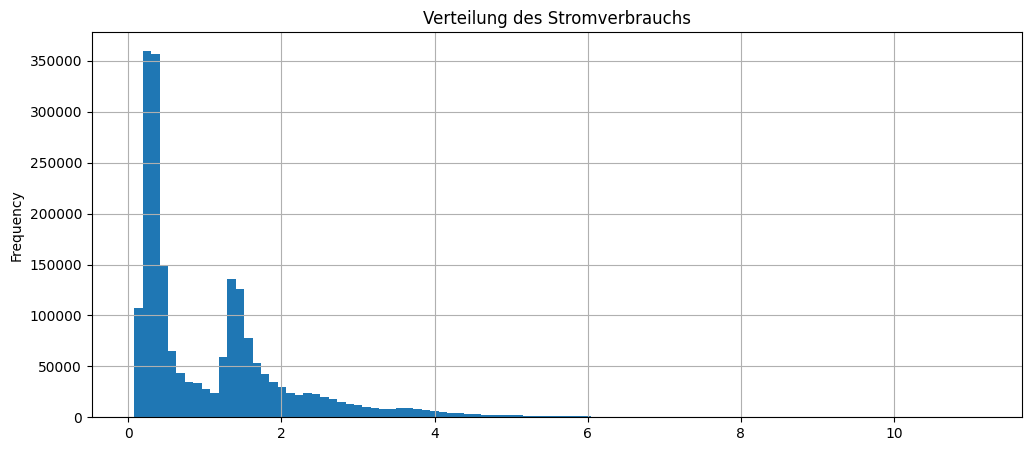

In [99]:
df['Global_active_power'].plot(kind='hist', bins=100)
plt.title("Verteilung des Stromverbrauchs")
plt.show()


### Beobachtungen: Verteilung des Stromverbrauchs (Histogramm)

- **Rechtssteil schiefe Verteilung (Right-Skewed):**  
  Die Mehrheit der Werte liegt zwischen **0 und 2 kW**, während hohe Verbrauchswerte selten sind.

- **Deutliche Grundlastzone:**  
  Am häufigsten treten Werte zwischen **0.2–0.6 kW** auf → typischer Grundverbrauch eines Haushalts.

- **Zweiter kleiner Peak um ~1–1.5 kW:**  
  Dieser Bereich deutet auf typische Lastspitzen hin (Kochen, Haushaltsgeräte).

- **Seltene Hochlastspitzen (>4 kW):**  
  Diese treten nur selten auf → mögliche Anomalien oder Nutzung großer Verbraucher (Ofen, Boiler).

- **Werte >6 kW sehr selten:**  
  Diese Extremwerte sind potenzielle Outlier → wichtig für Peak Detection & Anomalieerkennung.

- **Keine normalverteilte Struktur:**  
  → ML-Modelle wie IsolationForest sind hier sinnvoller als z-score-basierte Modelle.


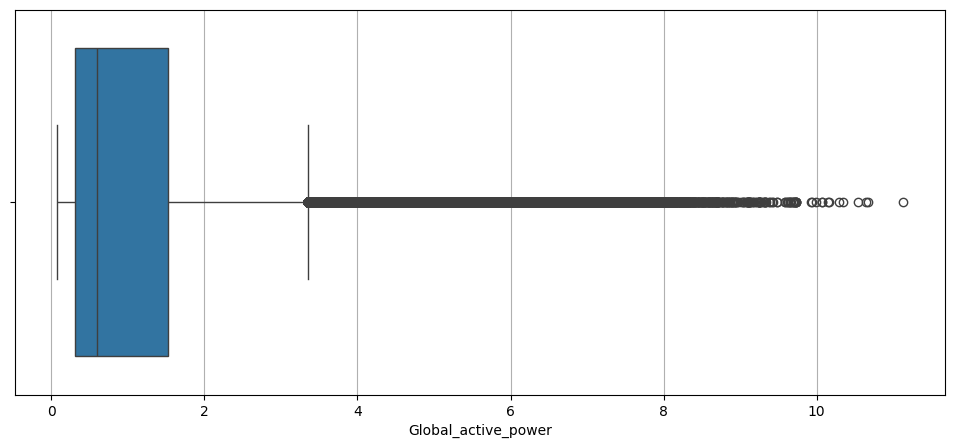

In [100]:
sns.boxplot(x=df['Global_active_power'])
plt.show()


###  Beobachtungen: Boxplot des Stromverbrauchs

- **Stark rechtsschiefe Verteilung:**  
  Der größte Teil der Werte liegt unter **2 kW**, während der Bereich darüber von vielen Ausreißern geprägt ist.

- **Große Anzahl von Ausreißern:**  
  Viele Werte oberhalb von **3 kW** werden als Outlier markiert.  
  → Diese Verbrauchsspitzen sind typisch für leistungsintensive Geräte (z. B. Herd, Boiler, Heizung).

- **Extremwerte bis über 10 kW:**  
  Diese seltenen Hochlastspitzen sind für spätere Anomaliedetektion besonders wichtig.

- **Median deutlich unter dem Boxplot-Oberrand:**  
  Bestätigt die hohe Konzentration des Verbrauchs auf niedrige Werte (Grundlast).

- **Breiter Whisker-Bereich:**  
  Zeigt, dass der Verbrauch stark schwankt — typisch für Haushaltsenergieprofile.

**Relevanz für das Projekt:**  
- Hohe Ausreißer bestätigen die Notwendigkeit von Peak-Detection und ML-basierten Anomalie-Modellen.  
- Für manche Modelle ist ggf. eine Log-Transformation sinnvoll, um extreme Werte abzuschwächen.  



## 5. Tages- und Wochenprofile

Ziele:
- Typische Tagesverläufe (0–23 Uhr) verstehen
- Unterschiede zwischen Werktagen und Wochenenden erkennen

In [64]:
# Neue Spalten für Stunde und Wochentag
# Hinweis: Der Index ist bereits ein DatetimeIndex

df['hour'] = df.index.hour
df['weekday'] = df.index.dayofweek

### 5.1 Durchschnittlicher Tagesverlauf

In [65]:
# Durchschnittlicher Verbrauch pro Stunde über alle Tage
hourly_profile = df.groupby('hour')['Global_active_power'].mean()

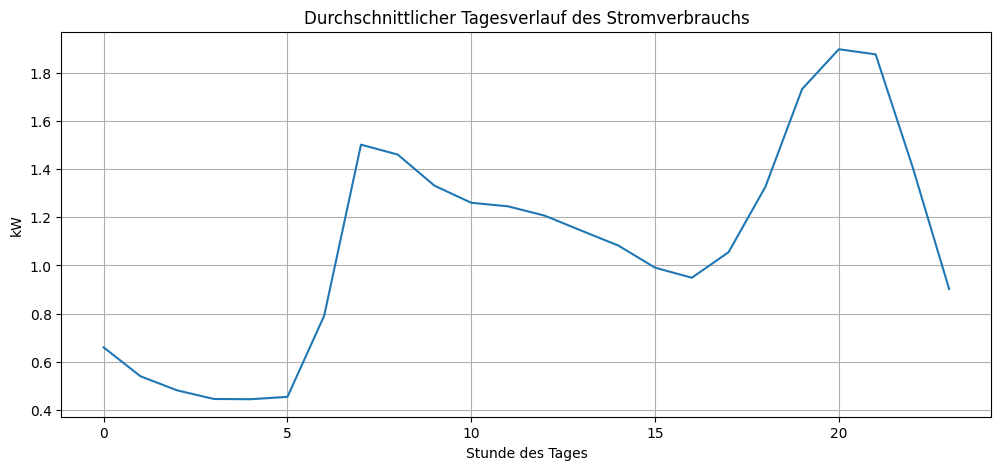

In [66]:
hourly_profile.plot(figsize=(12,5))
plt.title("Durchschnittlicher Tagesverlauf des Stromverbrauchs")
plt.xlabel("Stunde des Tages")
plt.ylabel("kW")
plt.grid(True)
plt.show()


### Beobachtungen: Durchschnittlicher Tagesverlauf

- **Nachtstunden (0–5 Uhr):**  
  Sehr niedriger und stabiler Verbrauch → reine Grundlast (Kühlschrank, Standby-Geräte, Heizungspumpe).

- **Morgenpeak (ca. 6–9 Uhr):**  
  Deutlicher Anstieg des Verbrauchs → typisches Haushaltsverhalten (Frühstück, Warmwasser, Aktivitäten vor der Arbeit).

- **Mittagsbereich (10–15 Uhr):**  
  Verbrauch sinkt und bleibt relativ stabil → weniger Haushaltsaktivität, besonders an Werktagen.

- **Abends (17–21 Uhr):**  
  **Stärkster Peak des Tages** → Kochen, Beleuchtung, Geräte, Warmwasser; hohe Aktivität im Haushalt.

- **Später Abend (22–24 Uhr):**  
  Abnahme des Verbrauchs, Rückkehr zum Grundlastniveau.

**Relevanz für spätere Schritte:**  
- Diese Muster helfen, ungewöhnliche Tagesverläufe zu erkennen (Anomalien).  
- Morgen- und Abendpeaks sind erwartbare „normale“ Spitzen — ML-Modelle sollten diese nicht als Outlier markieren.  
- Grundlastbereiche sind wichtig als Referenz für minimalen Verbrauch.


### 5.2 Werktage vs. Wochenende

In [67]:
# Werktage: Montag (0) bis Freitag (4)
weekday_profile = (
    df[df['weekday'] < 5]
    .groupby('hour')['Global_active_power']
    .mean()
)


In [68]:
# Wochenende: Samstag (5) und Sonntag (6)
weekend_profile = (
    df[df['weekday'] >= 5]
    .groupby('hour')['Global_active_power']
    .mean()
)


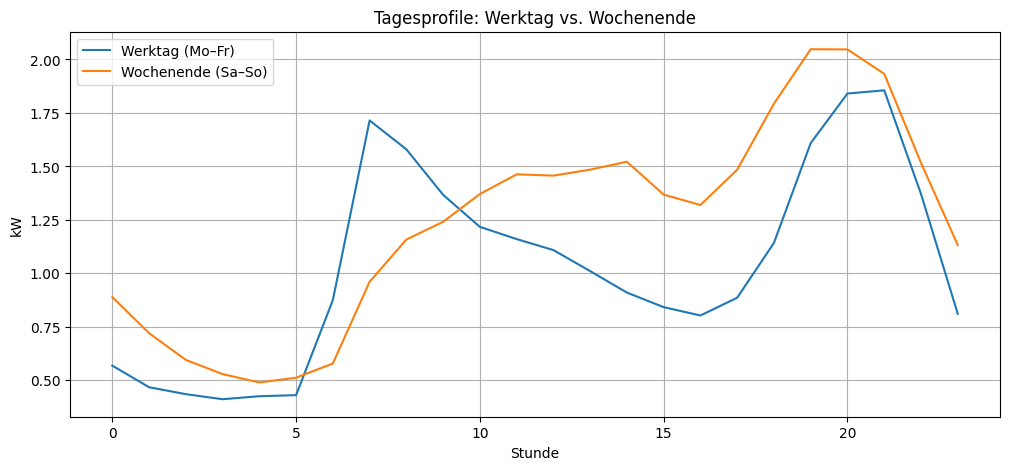

In [69]:
plt.figure(figsize=(12,5))

plt.plot(weekday_profile, label="Werktag (Mo–Fr)")
plt.plot(weekend_profile, label="Wochenende (Sa–So)")

plt.title("Tagesprofile: Werktag vs. Wochenende")
plt.xlabel("Stunde")
plt.ylabel("kW")
plt.legend()
plt.grid(True)
plt.show()


###  Beobachtungen: Tagesprofile – Werktag vs. Wochenende

- **Grundlast in der Nacht (0–5 Uhr):**  
  Ähnlich an allen Tagen, aber am Wochenende leicht höher → späteres Schlafen / mehr Geräte im Standby.

- **Morgenverhalten unterscheidet sich deutlich:**
  - **Werktage:** Früher und steiler Anstieg ab ca. 6 Uhr → typische Arbeitsroutine.
  - **Wochenende:** Späterer, flacherer Anstieg → Haushalt startet später in den Tag.

- **Mittagszeit (10–15 Uhr):**  
  - Werktage: geringere Last durch Abwesenheit.  
  - Wochenende: gleichmäßig erhöhter Verbrauch → mehr Aktivität zuhause.

- **Abendpeak (18–21 Uhr):**  
  - Auf **beiden** Profilen stärkster Peak des Tages.  
  - Wochenende zeigt **höheren Spitzenwert** und etwas spätere Verbrauchsspitze.

- **Später Abend (21–23 Uhr):**  
  Am Wochenende länger hohe Werte → längere Aktivität im Haushalt.

**Relevanz für die Anomalieerkennung:**  
- ML-Modelle müssen unterschiedliche Tagesmuster kennen, sonst werden Wochenendspitzen fälschlich als Anomalien markiert.  
- Diese Profile bilden eine Basis für Feature Engineering (z. B. „is_weekend“, „hour“).


## 6. Saisonale Muster

Ziele:
- Trends und längerfristige Muster erkennen
- Wöchentliche und monatliche Verbrauchsverläufe betrachten
- Gleitende Durchschnitte und Volatilität analysieren


### 6.1 Wöchentlicher Verbrauch

In [71]:
# Wöchentlicher Durchschnittsverbrauch
weekly_consumption = df['Global_active_power'].resample('W').mean()


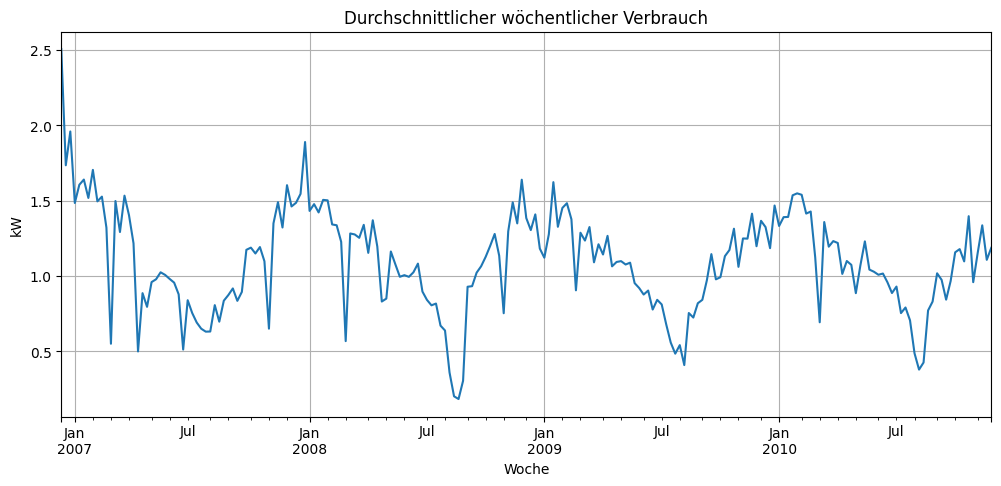

In [72]:
weekly_consumption.plot(figsize=(12,5))
plt.title("Durchschnittlicher wöchentlicher Verbrauch")
plt.xlabel("Woche")
plt.ylabel("kW")
plt.grid(True)
plt.show()


###  Beobachtungen: Durchschnittlicher wöchentlicher Verbrauch

- **Deutliche saisonale Schwankungen:**  
  Der Verbrauch steigt im Winter deutlich an und fällt im Sommer ab – ein typisches Muster durch Heizung, Licht und Haushaltsaktivität.

- **Stärkere Peaks in Wintermonaten:**  
  Insbesondere Anfang 2007, Ende 2007, Anfang 2009 und Anfang 2010 treten klare Wochen-Spitzen auf.

- **Sommerminima sehr niedrig:**  
  Besonders Mitte 2008 und Mitte 2010 sinkt der wöchentliche Durchschnitt deutlich ab → geringer Energiebedarf (Heizung aus, mehr Tageslicht).

- **Trends über die Jahre:**  
  - 2007 → relativ hohe Variabilität  
  - 2008 → stabiler, aber niedriger Durchschnitt  
  - 2009 → wieder höhere Werte im Winter  
  - 2010 → insgesamt niedrigeres Verbrauchsniveau

- **Kurzfristige Einbrüche:**  
  Einige starke Drops sind vermutlich **Messausfälle**, nicht echter Verbrauchsverlust.

**Relevanz für spätere Schritte:**  
- Wochenmuster eignen sich gut als Feature (z. B. „week_of_year“).  
- Saisonale Schwankungen müssen Anomalie-Modelle berücksichtigen, um echte von saisonalen Peaks zu unterscheiden.  
- Wöchentliche Trends sind hilfreich für Forecasting und Power BI Visualisierungen.


### 6.2 Monatlicher Verbrauch

In [73]:
monthly_consumption = df['Global_active_power'].resample('M').mean()


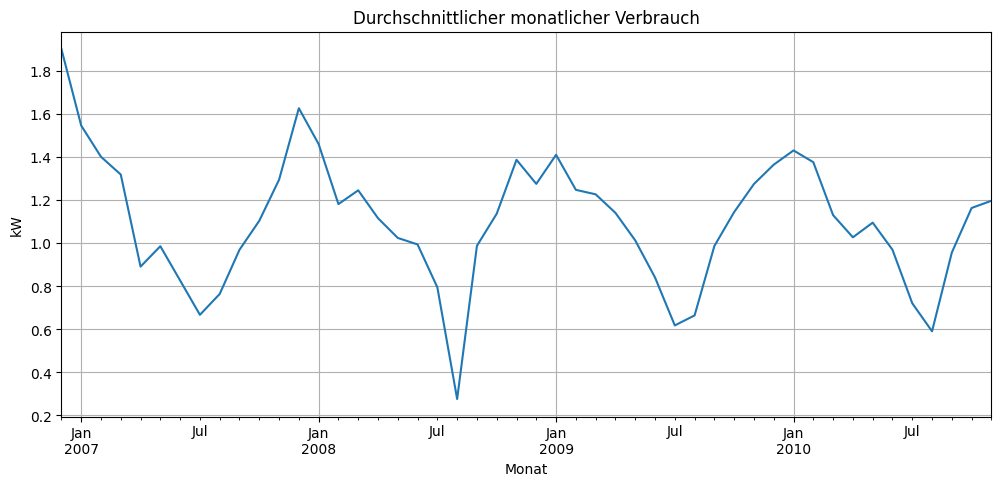

In [74]:
monthly_consumption.plot(figsize=(12,5))
plt.title("Durchschnittlicher monatlicher Verbrauch")
plt.xlabel("Monat")
plt.ylabel("kW")
plt.grid(True)
plt.show()


###  Beobachtungen: Durchschnittlicher monatlicher Verbrauch

- **Klares saisonales Muster:**  
  In jedem Jahr steigt der Stromverbrauch im Winter deutlich an und fällt im Sommer ab.  
  → typisch für Heizgeräte, Warmwasser, Licht und höhere Indoor-Aktivität.

- **Wintermonate (Dez–Feb):**  
  Höchster monatlicher Verbrauch, mehrfach über **1.4–1.8 kW** im Durchschnitt.

- **Sommermonate (Jun–Aug):**  
  Deutlich niedrigere Werte zwischen **0.6–0.9 kW**, zeitweise sogar unter 0.5 kW (Juni 2008).

- **Ausreißer nach unten:**  
  Ein extrem niedriger Wert Mitte 2008 deutet vermutlich auf eine **Messlücke** hin.

- **Jahresvergleiche:**  
  - Winter 2007/2008 und 2009/2010 sind ähnlich stark ausgeprägt.  
  - Ab 2010 sinkt das durchschnittliche Verbrauchsniveau leicht → möglicher Verhaltens- oder Gerätewechsel.

**Relevanz für folgende Schritte:**  
- Saisonale Muster müssen in der Anomalieerkennung berücksichtigt werden, damit Winterpeaks nicht fälschlich als Outlier gelten.  
- Monatsverläufe eignen sich gut für Power BI Dashboards und für Forecasting (Prophet o. Ä.).  
- Die deutlichen Wiederholungsmuster bestätigen eine starke jährliche Saisonalität im Haushalt.


### 6.3 Rolling Mean & Rolling Std (z. B. 24h)

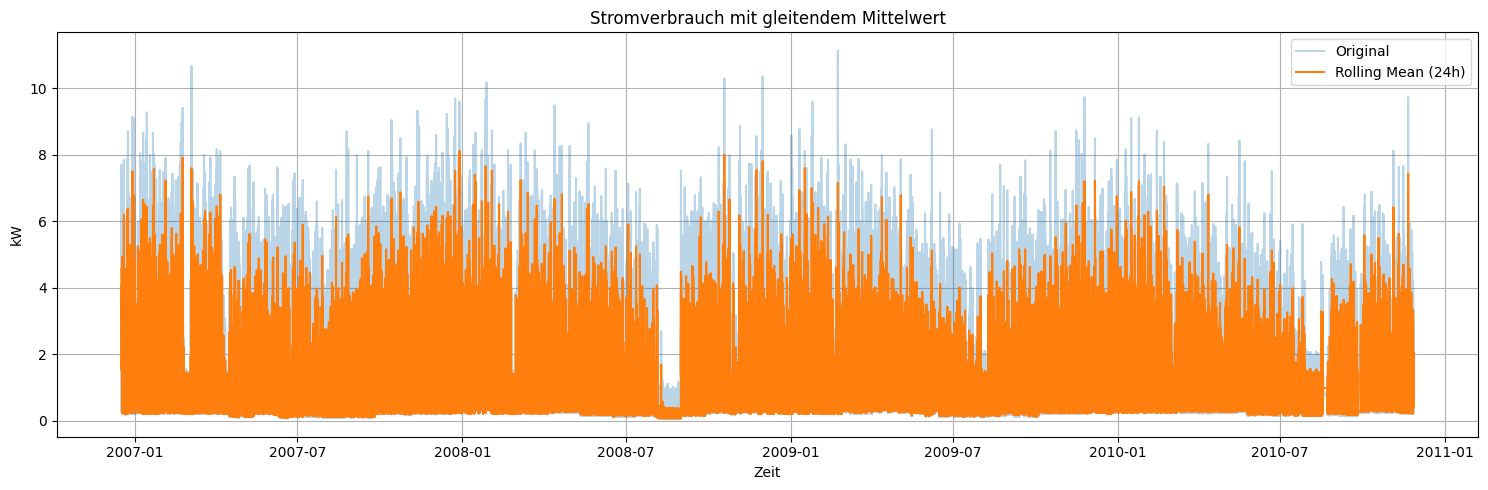

In [101]:
# Rolling-Fenster: hier 24 Stunden
# Achtung: Fenstergröße ggf. an Sampling-Rate anpassen
rolling_window = 24

df["rolling_mean_24h"] = df["Global_active_power"].rolling(rolling_window).mean()
df["rolling_std_24h"] = df["Global_active_power"].rolling(rolling_window).std()

plt.figure(figsize=(15, 5))
plt.plot(df["Global_active_power"], alpha=0.3, label="Original")
plt.plot(df["rolling_mean_24h"], label=f"Rolling Mean ({rolling_window}h)")
plt.title("Stromverbrauch mit gleitendem Mittelwert")
plt.xlabel("Zeit")
plt.ylabel("kW")
plt.legend()
plt.tight_layout()
plt.show()




### Beobachtungen: Gleitender Mittelwert (24h)

- **Glättung der täglichen Schwankungen:**  
  Der gleitende Mittelwert reduziert die hohen kurzfristigen Peaks und zeigt klarere Trends im Verbrauch.

- **Saisonale Muster weiterhin sichtbar:**  
  Wintermonate liegen deutlich über dem Verbrauchsniveau der Sommermonate.

- **Langfristige Verbrauchsänderungen:**  
  - 2007–2009: leicht steigender Grundtrend  
  - 2010: insgesamt niedrigere Verbrauchsniveaus → möglicher Geräte- oder Verhaltenswechsel

- **Messausfälle deutlich erkennbar:**  
  Tiefe Ausreißer in 2008 und 2010 → nicht realer Verbrauch, sondern fehlende Datenpunkte.

**Nutzen für spätere Schritte:**  
- Basis zum Erkennen von langfristigen Trends.  
- Hilft ML-Modellen, Output besser zu interpretieren.  
- Dient als Referenzlinie für Anomalien auf Tagesbasis.

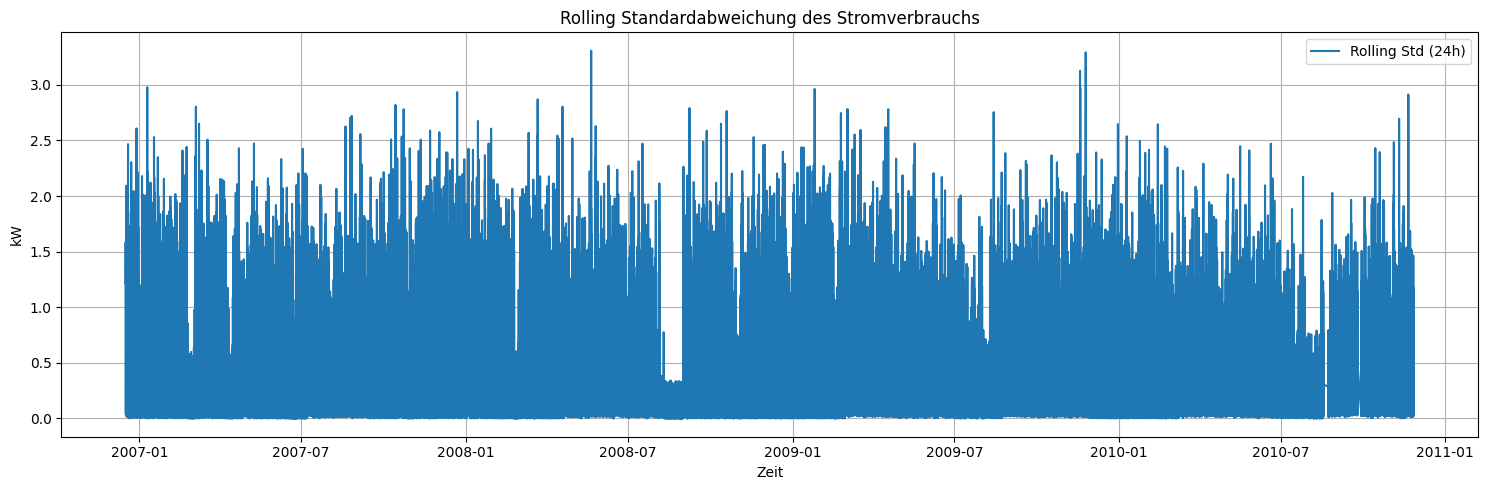

In [102]:
plt.figure(figsize=(15, 5))
plt.plot(df["rolling_std_24h"], label=f"Rolling Std ({rolling_window}h)")
plt.title("Rolling Standardabweichung des Stromverbrauchs")
plt.xlabel("Zeit")
plt.ylabel("kW")
plt.legend()
plt.tight_layout()
plt.show()

###  Beobachtungen: Rolling Standardabweichung (24h)

- **Indikator für Verbrauchsvolatilität:**  
  Hohe Standardabweichungen bedeuten, dass innerhalb eines Tages starke Schwankungen auftreten (z. B. viele Geräte ein/aus).

- **Wiederkehrende Spitzen im Winter:**  
  Tagesvariabilität ist im Winter höher – typisch für mehr Haushaltsaktivität und Heizungsgeräte.

- **Geringere Variabilität im Sommer:**  
  Sommermonate zeigen deutlich niedrigere Standardabweichungen → stabilerer Tagesverbrauch.

- **Messausfälle beeinflussen Std-Werte:**  
  Die extrem niedrigen Std-Phasen (nahe 0) korrespondieren mit Datenlücken.

- **Peaks der Standardabweichung korrelieren oft mit Verbrauchsspitzen:**  
  Tage mit Ausreißern und hoher Aktivität zeigen große Std-Ausschläge.

**Nutzen für spätere Schritte:**  
- Wichtige Größe für Feature Engineering bei Anomalieerkennung.  
- Tage mit ungewöhnlich hoher Variabilität können Indikatoren für Störungen oder defekte Geräte sein.


## 7. Peak Detection (ohne Machine Learning)

Ziele:
- Extreme Verbrauchsspitzen identifizieren
- Baseline für spätere Anomalie-Modelle (Isolation Forest etc.)
Methoden:
- Z-Score
- Top-1% Werte


### 7.1 Z-Score-basierte Peaks

In [77]:
# Z-Score des Global Active Power
mean_gap = df["Global_active_power"].mean()
std_gap = df["Global_active_power"].std()

df["zscore_gap"] = (df["Global_active_power"] - mean_gap) / std_gap

# Schwelle: hier |Z| > 3 als Peak
df["zscore_peak"] = df["zscore_gap"].abs() > 3

print("Anzahl Z-Score Peaks:", df["zscore_peak"].sum())


Anzahl Z-Score Peaks: 36160


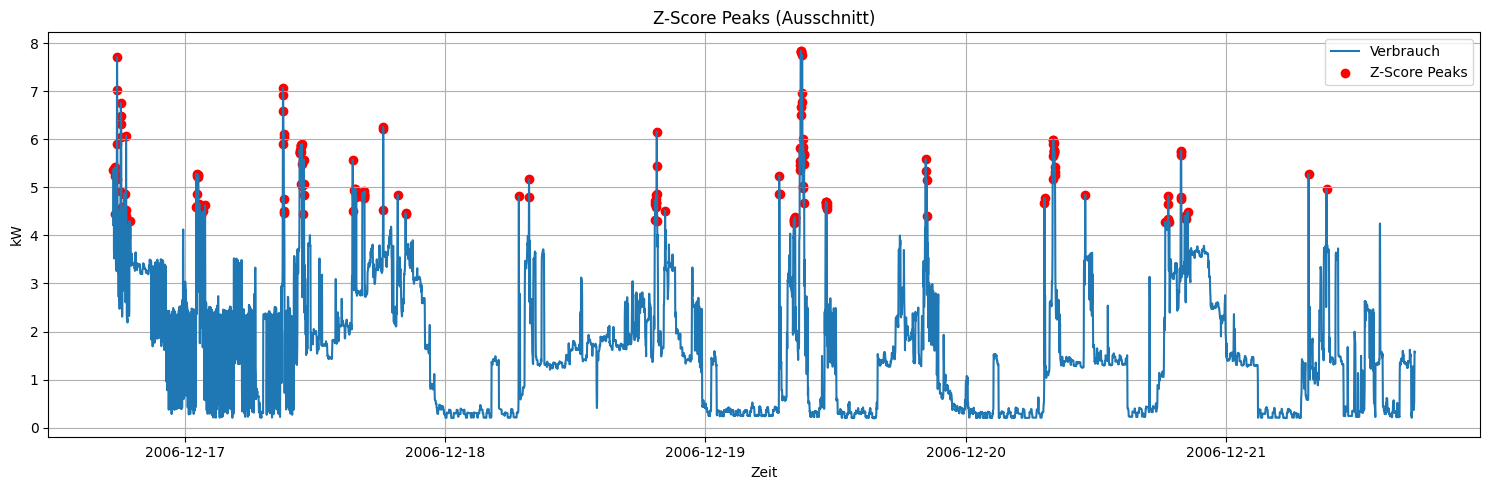

In [78]:
# Visualisierung für einen begrenzten Zeitraum (z. B. erste 5 Tage)
ausschnitt = df.iloc[:5 * 24 * 60]  # ggf. an Sampling-Rate anpassen

plt.figure(figsize=(15, 5))
plt.plot(ausschnitt["Global_active_power"], label="Verbrauch")
plt.scatter(
    ausschnitt.index[ausschnitt["zscore_peak"]],
    ausschnitt["Global_active_power"][ausschnitt["zscore_peak"]],
    color="red",
    label="Z-Score Peaks"
)
plt.title("Z-Score Peaks (Ausschnitt)")
plt.xlabel("Zeit")
plt.ylabel("kW")
plt.legend()
plt.tight_layout()
plt.show()


### Beobachtungen: Z-Score Peaks (Ausschnitt)

- **Z-Score identifiziert starke Spitzen korrekt:**  
  Die roten Punkte markieren Zeitpunkte, an denen der Verbrauch signifikant über dem lokalen Mittelwert liegt.

- **Peaks folgen typischen Haushaltsmustern:**  
  Viele Spitzen treten morgens und abends auf → erwartbare hohe Nutzung (Kochen, Warmwasser, Geräte).

- **Mehrere hochfrequente Peaks in kurzer Zeit:**  
  Weist auf kurze Lastzyklen hin (z. B. Wasserkocher, Herd, Waschmaschine).

- **Z-Score reagiert empfindlich auf starke Ausreißer:**  
  Extremwerte > 7–8 kW werden zuverlässig hervorgehoben.

- **Z-Score erkennt keine „Trendabweichungen“:**  
  Der Algorithmus markiert nur punktuelle Peaks, aber keine längerfristigen Veränderungen oder ungewöhnliche Tagesformen.

- **Nicht jeder markierte Peak ist eine echte Anomalie:**  
  Viele Peaks sind *normale Verhaltensspitzen* und sollten später durch ML-Modelle (z. B. Isolation Forest) besser klassifiziert werden.

**Einsatz für spätere Schritte:**  
- Z-Score dient als **Baseline-Modell** für Anomalieerkennung.  
- Ergebnisse helfen beim **Vergleich mit ML-Modellen** (Benchmark).  
- Peak-Positionen können später


### 7.2 Top-1% Verbrauchswerte als Peaks

In [79]:
# 99%-Quantil als Schwelle für "Top 1%" Peaks
threshold_top1 = df["Global_active_power"].quantile(0.99)
df["top1_peak"] = df["Global_active_power"] > threshold_top1

print("Anzahl Top-1%-Peaks:", df["top1_peak"].sum())


Anzahl Top-1%-Peaks: 20473


In [85]:
# 1) Top-1%-Schwelle berechnen
threshold_top1 = df["Global_active_power"].quantile(0.99)

# 2) Boolean-Spalte anlegen: True = Peak
df["top1_peak"] = df["Global_active_power"] > threshold_top1

# Kontrollieren:
df[["Global_active_power", "top1_peak"]].head()


,Global_active_power,top1_peak
Datetime,,
2006-12-16 17:24:00,4.216,False
2006-12-16 17:25:00,5.360,True
2006-12-16 17:26:00,5.374,True
2006-12-16 17:27:00,5.388,True
2006-12-16 17:28:00,3.666,False


In [86]:
# Beispiel: erster Zeitraum (z.B. 5 Tage – je nach Samplingrate anpassen)
ausschnitt = df.iloc[:5 * 24 * 60]  # falls 1-Minuten-Daten


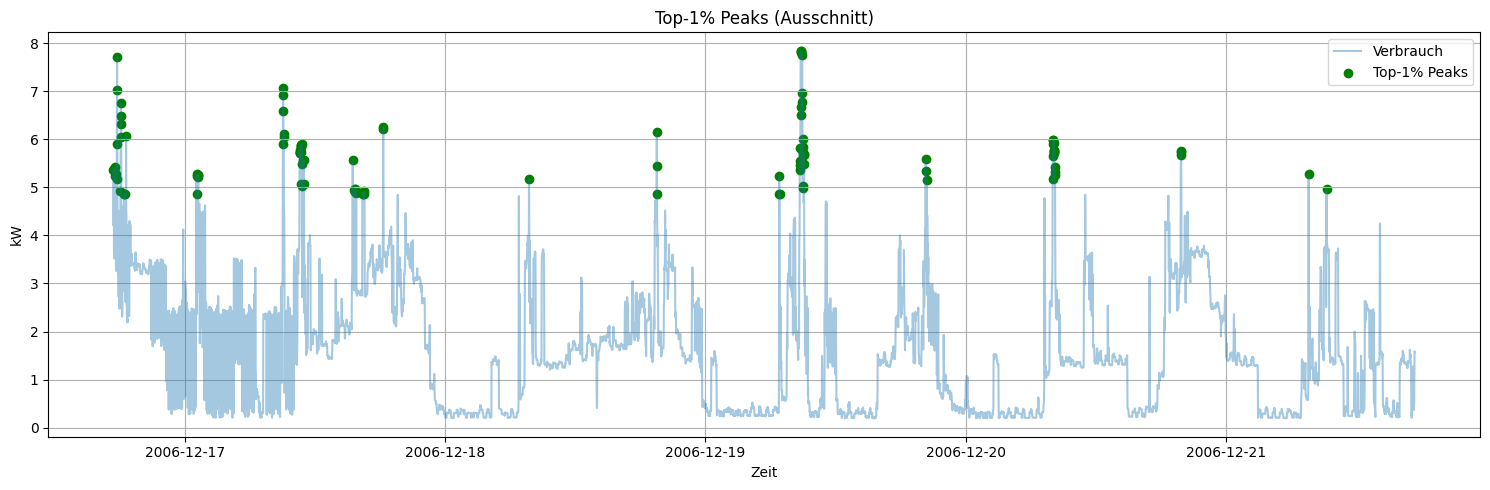

In [87]:
plt.figure(figsize=(15, 5))

# Verbrauch im Ausschnitt
plt.plot(ausschnitt["Global_active_power"], alpha=0.4, label="Verbrauch")

# Nur die Zeilen im Ausschnitt, wo top1_peak == True
peaks = ausschnitt[ausschnitt["top1_peak"]]

plt.scatter(
    peaks.index,
    peaks["Global_active_power"],
    color="green",
    label="Top-1% Peaks"
)

plt.title("Top-1% Peaks (Ausschnitt)")
plt.xlabel("Zeit")
plt.ylabel("kW")
plt.legend()
plt.tight_layout()
plt.show()


###  Beobachtungen: Top-1% Peaks (Ausschnitt)

- Die Top-1% Methode markiert die **absolut höchsten Verbrauchswerte** im Datensatz.
- Die meisten Spitzen liegen im Bereich **5–8 kW**, deutlich über dem normalen Tagesverbrauch.
- Peaks treten häufig morgens und abends auf → typische Hochlastzeiten im Haushalt.
- Die Methode identifiziert zuverlässig wenige, aber sehr starke Lastspitzen.
- Im Vergleich zum Z-Score erkennt diese Methode **globale Extremwerte**, während der Z-Score **lokale Ausreißer** hervorhebt.


## 8. Korrelationsanalyse der Energievariablen

Ziel:
- Beziehungen zwischen den verschiedenen Messgrößen verstehen
- Relevante Features für spätere Modelle identifizieren


In [89]:
corr_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

corr_matrix = df[corr_cols].corr()
corr_matrix


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.000000,0.247017,-0.399762,0.998889,0.484401,0.434569,0.638555
Global_reactive_power,0.247017,1.000000,-0.112246,0.266120,0.123111,0.139231,0.089617
Voltage,-0.399762,-0.112246,1.000000,-0.411363,-0.195976,-0.167405,-0.268172
Global_intensity,0.998889,0.266120,-0.411363,1.000000,0.489298,0.440347,0.626543
Sub_metering_1,0.484401,0.123111,-0.195976,0.489298,1.000000,0.054721,0.102571
Sub_metering_2,0.434569,0.139231,-0.167405,0.440347,0.054721,1.000000,0.080872
Sub_metering_3,0.638555,0.089617,-0.268172,0.626543,0.102571,0.080872,1.000000


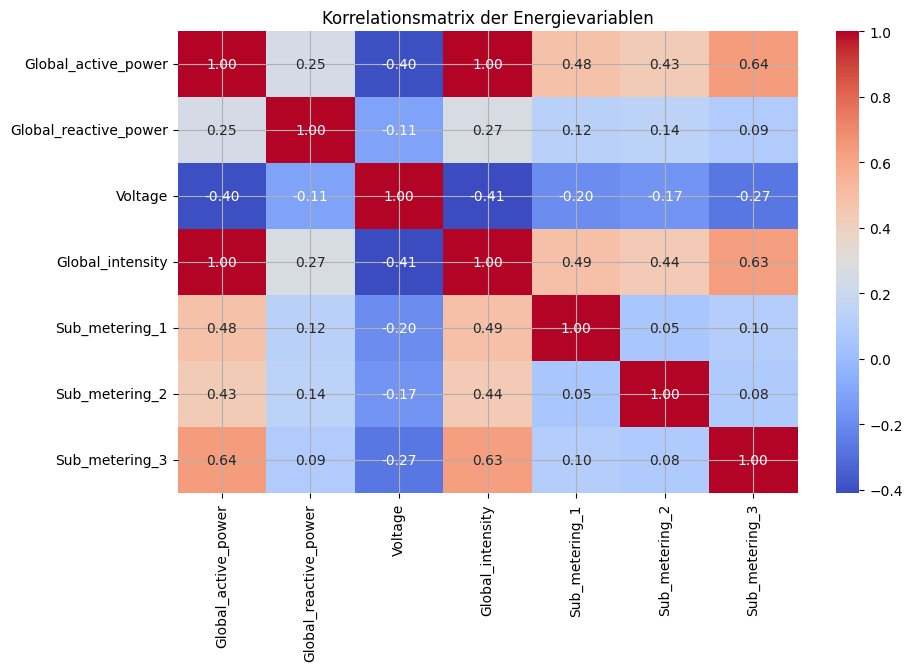

In [90]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korrelationsmatrix der Energievariablen")
plt.show()


###  Beobachtungen: Korrelationsmatrix der Energievariablen

- **Sehr starke Korrelation zwischen „Global_active_power“ und „Global_intensity“ (1.00):**  
  Beide messen ähnliche physikalische Größen (Leistung ↔ Stromstärke).  
  → Redundanz im Modell, eine der beiden Variablen kann später ggf. entfallen.

- **Starke positive Korrelation von „Sub_metering_3“ mit dem Gesamtverbrauch (0.64):**  
  Dieser Kanal trägt signifikant zu Lastspitzen bei – Hinweis auf ein großes Haushaltsgerät (z. B. Boiler/Heizung).

- **Sub_metering_1 und Sub_metering_2 nur schwach korreliert:**  
  Beide messen unterschiedliche Verbrauchergruppen und liefern somit **ergänzende Informationen**.

- **Voltage zeigt schwache oder negative Korrelationen:**  
  Spannung schwankt unabhängig vom Verbrauch.  
  → Für Anomalieerkennung weniger relevant, eher für technische Analysen.

- **Global_reactive_power schwach korreliert:**  
  Blindleistung ist im Haushalt weniger verbrauchsrelevant, kann aber für Geräteverhalten informativ sein.

- **Allgemeiner Trend:**  
  Die Submetering-Kanäle erklären einen Teil des Gesamtverbrauchs, aber keine dominiert vollständig.  
  → Das Systemverhalten des Haushalts ist **mehrdimensional**, was ML-Modelle gut nutzen können.

**Relevanz für spätere Schritte:**  
- Feature Engineering: „Global_active_power“ und „Global_intensity“ nicht gleichzeitig verwenden.  
- Sub_metering_3 ist ein wichtiger Indikator für Lastspitzen → relevant für Anomalien.  
- Voltage kann optional weggelassen werden, wenn Modelle sensitiv auf irrelevante Features reagieren.


Wert	Bedeutung
+1.0	perfekt positive Korrelation (steigen zusammen)
0	keine lineare Beziehung
−1.0	perfekt negative Korrelation (einer steigt, anderer fällt)

## 9. Wichtige Visualisierungen speichern

Die folgenden Plots werden für README, Präsentationen und Power BI gespeichert.

Visualisierungen gespeichert.


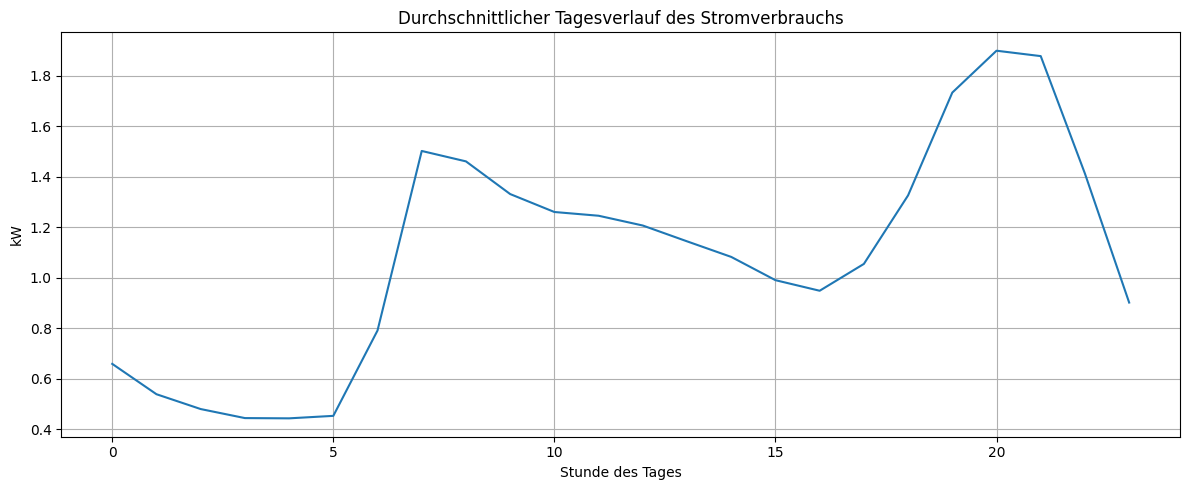

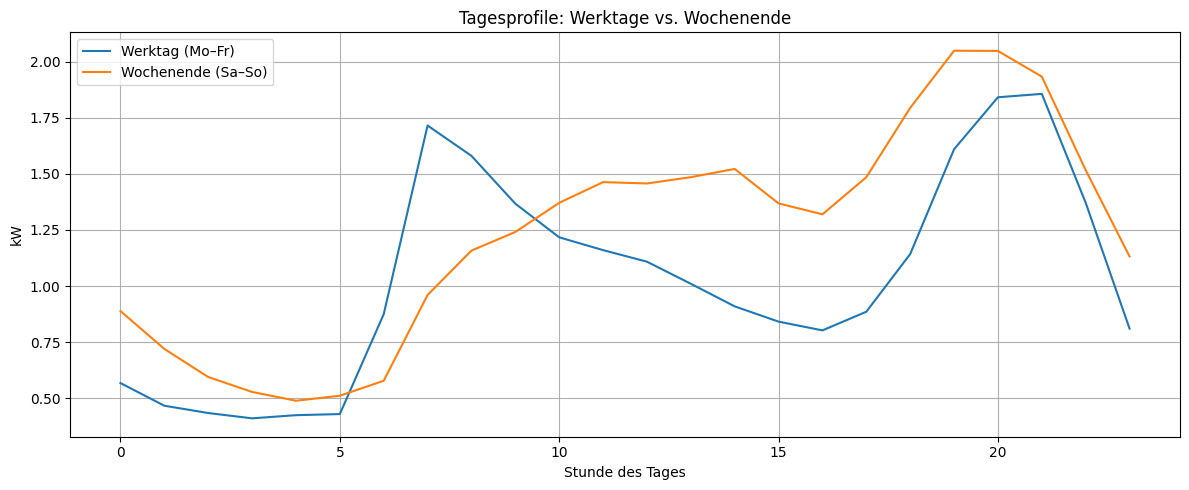

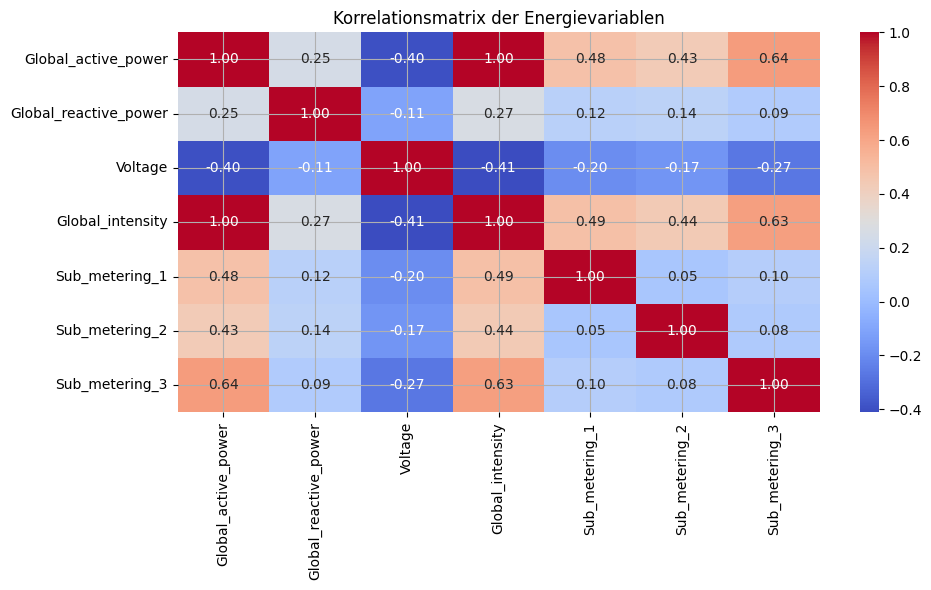

In [84]:
# Ordnerstruktur: img/eda/ (manuell anlegen oder per Code)
import os

os.makedirs("img/eda", exist_ok=True)

# Beispiel: Tagesprofil
plt.figure()
hourly_profile.plot()
plt.title("Durchschnittlicher Tagesverlauf des Stromverbrauchs")
plt.xlabel("Stunde des Tages")
plt.ylabel("kW")
plt.tight_layout()
plt.savefig("img/eda/daily_profile.png", dpi=300)

# Beispiel: Werktag vs. Wochenende
plt.figure()
plt.plot(weekday_profile, label="Werktag (Mo–Fr)")
plt.plot(weekend_profile, label="Wochenende (Sa–So)")
plt.title("Tagesprofile: Werktage vs. Wochenende")
plt.xlabel("Stunde des Tages")
plt.ylabel("kW")
plt.legend()
plt.tight_layout()
plt.savefig("img/eda/weekday_vs_weekend.png", dpi=300)

# Beispiel: Korrelationsmatrix
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korrelationsmatrix der Energievariablen")
plt.tight_layout()
plt.savefig("img/eda/correlation_matrix.png", dpi=300)

print("Visualisierungen gespeichert.")


## 10. Fazit der EDA

- Typische Tagesmuster wurden identifiziert (morgens/abends Peaks).
- Unterschiede zwischen Werktagen und Wochenenden sind sichtbar.
- Saisonale Muster (wöchentlich/monatlich) zeigen Trends und mögliche saisonale Effekte.
- Erste Peak-Detection ohne ML (Z-Score, Top-1%) liefert Kandidaten für Anomalien.
- Korrelationsanalyse zeigt starke Zusammenhänge zwischen Global_active_power und Global_intensity sowie den Sub-Metering-Kanälen.

Diese Erkenntnisse bilden die Grundlage für:
- Notebook 3: Anomalieerkennung (Isolation Forest, Rolling Z-Score)
- Notebook 4 (optional): Forecasting mit Prophet
- Streamlit-App und Power BI Dashboards.


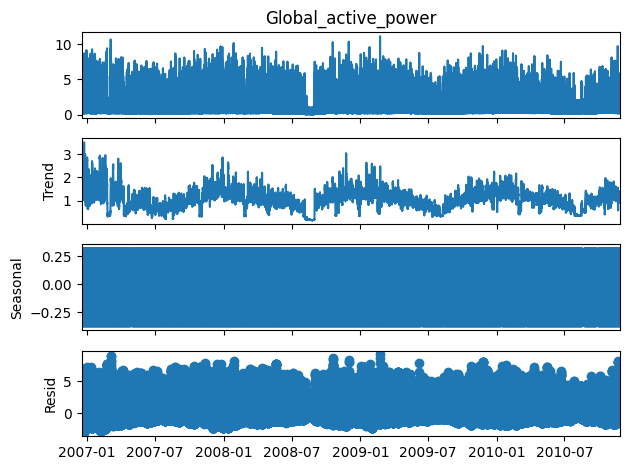

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['Global_active_power'], model='additive', period=1440)  # 1440 = Minuten pro Tag
result.plot()
plt.show()


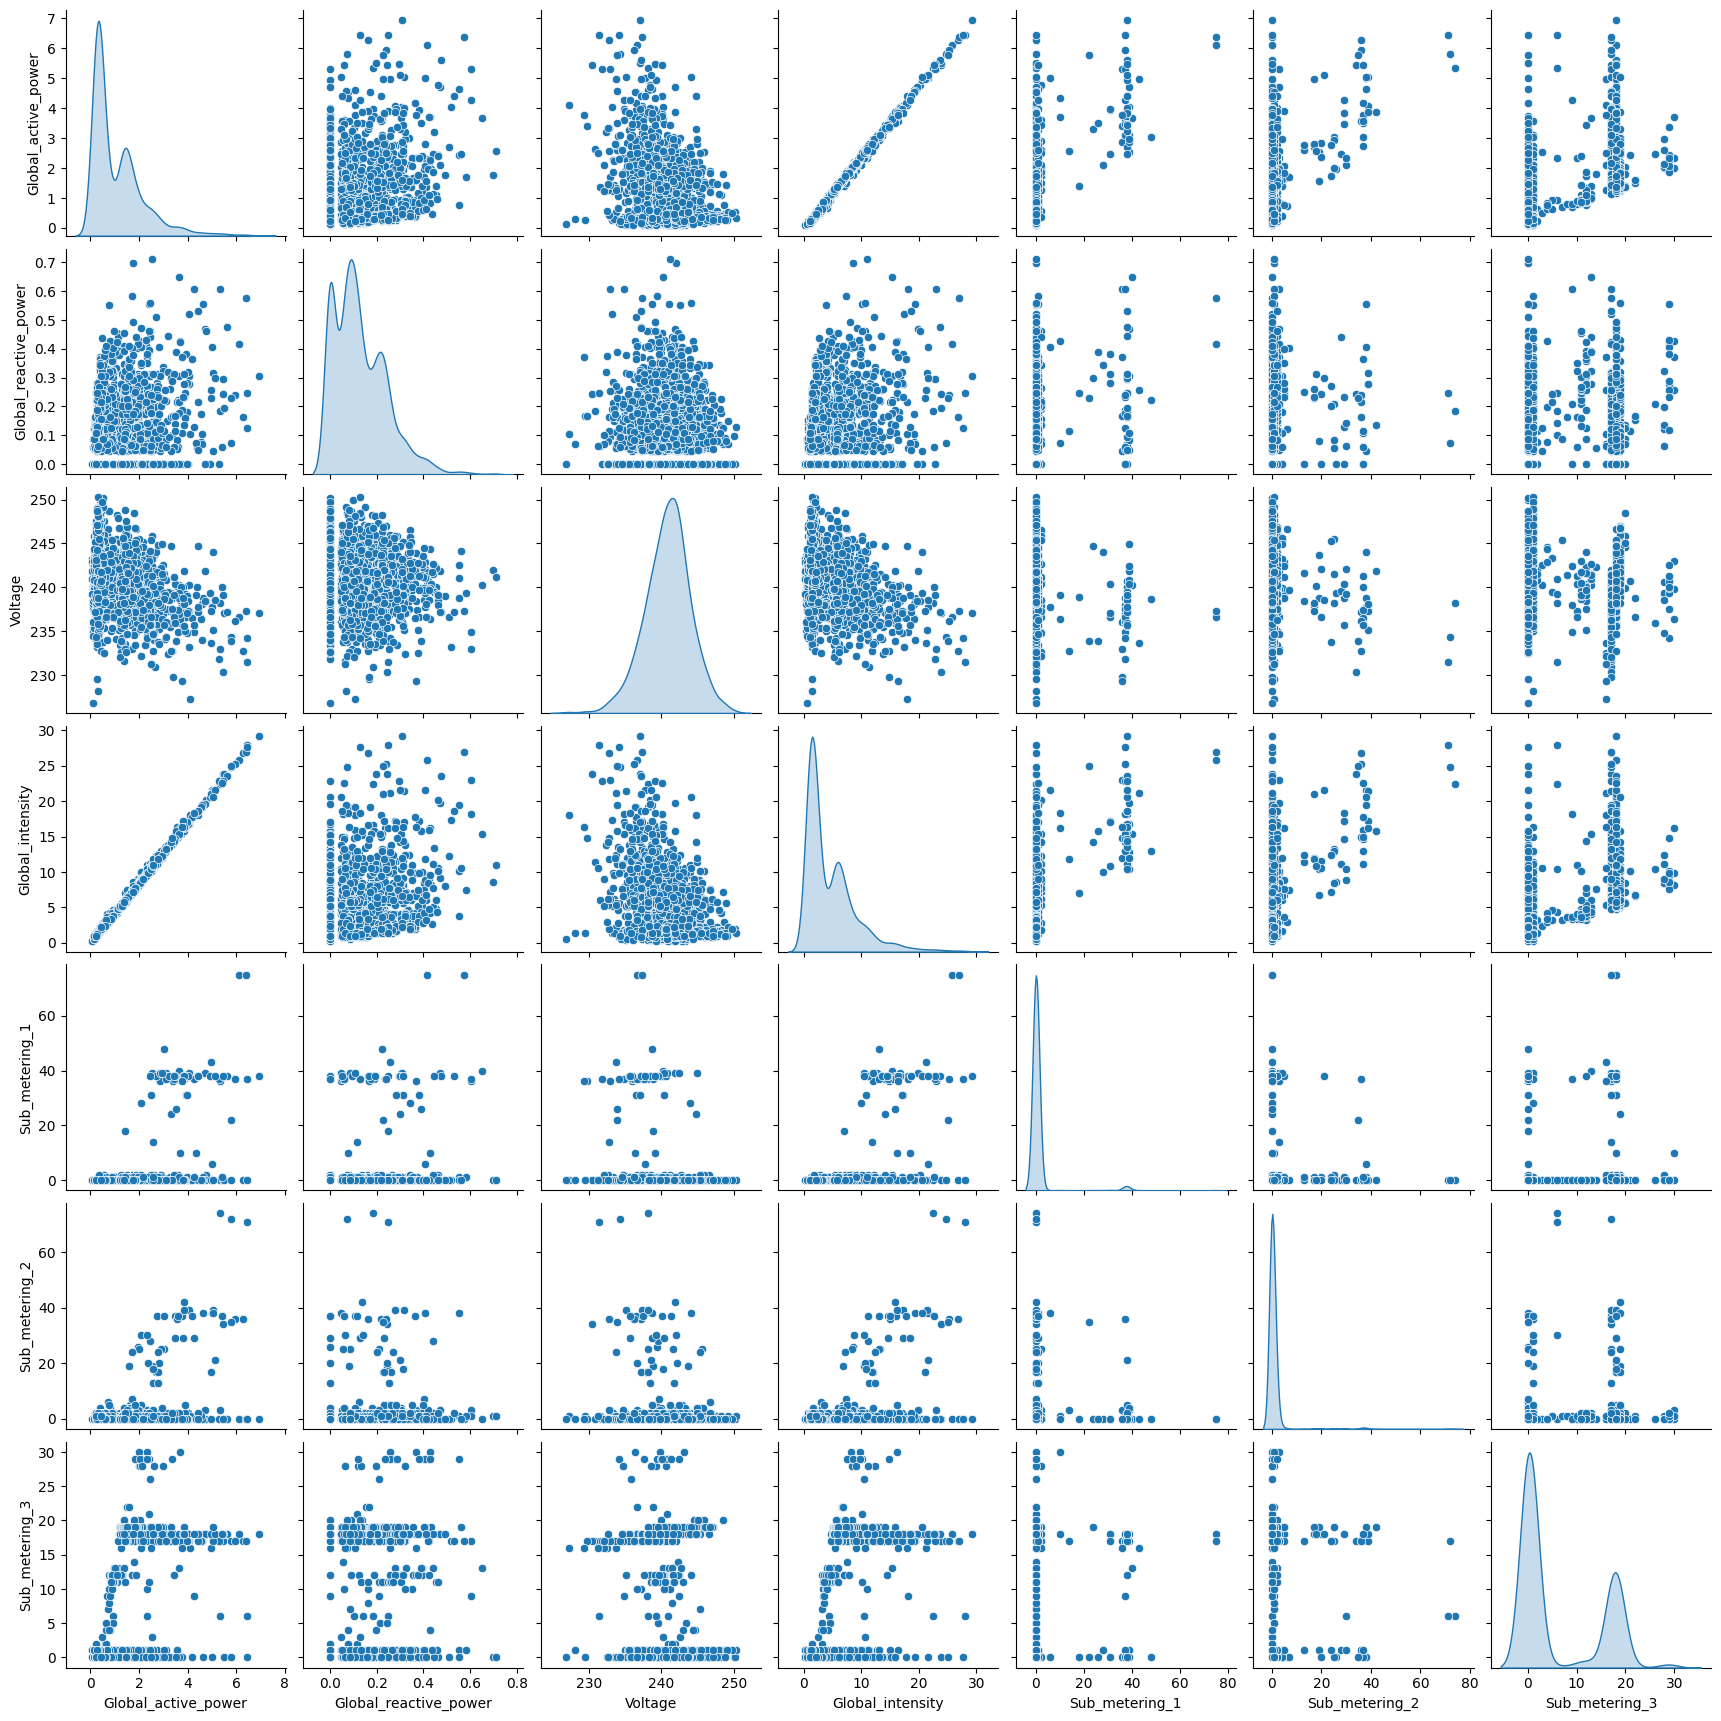

In [49]:
sns.pairplot(df[corr_cols].sample(2000), diag_kind="kde")
plt.show()


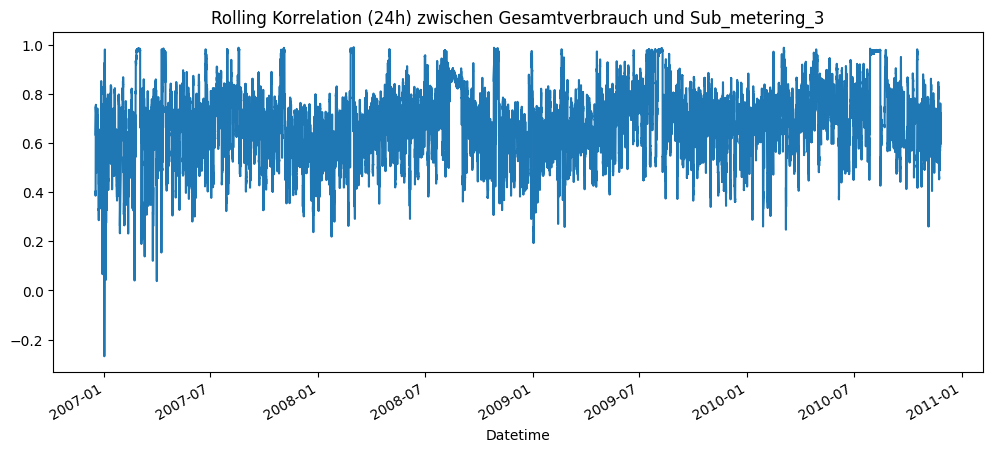

In [50]:
rolling_corr = df['Global_active_power'].rolling(24*60).corr(df['Sub_metering_3'])
rolling_corr.plot(figsize=(12,5))
plt.title("Rolling Korrelation (24h) zwischen Gesamtverbrauch und Sub_metering_3")
plt.show()
